
Técnicas de Inteligencia Artificial

_MU en Análisis y Visualización de datos masivos_

# Árboles de decisión vs Random Forest

## Objetivos

Este cuaderno persigue conocer cómo se resuelve un **problema de clasificación** utilizando los algoritmos de aprendizaje supervisado **Árboles de decisión y Random Forest ** y comparar los resultados obtenidos a fin de elegir la mejor técnica de clasificación en base al conjunto de datos proporcionado y por tanto:

- Comprender cómo funciona  del algoritmo Árboles de decisión aplicado a un problema de clasificación.
- Comprender cómo funciona el algoritmo Random Forest aplicado a un problema de clasificación.
- Aprender a  interpretar las distintas métricas de evaluación de los distintos algoritmos de clasificación.


## Descripción de la actividad

El problema específico que queremos resolver es predecir si un pasajero sobrevirá al naufragio o no. Es decir, predecir la probabilidad de que un pasajero pertenezca a la Clase 0 (NO sobrevive) y 1 (Sobrevive).


## Descripción de los datos

- **PassengerId** = identificador único de cada pasajero
- **Name** = nombre del pasajero
- **Sex** = factor, con niveles (masculino y femenino)
- **Age** = edad del pasajero
- **Pclass** = clase eb la que viajaba el pasajero
embarked = lugar en el que embarcó el pasajero
- **Ticket** = número de ticket del pasajero (na para la tripulación)
- **Fare** = precio del ticket (na para la tripulación, musicos,
empleados y otros)
- **SibSp** = número de hermanos/familiares
- **Cabin** = cabina que ocupa cada pasajero
- **Parch** = número de padres e hijos a bordo
- **Survived** = especifica si el pasajero sobrevivió al hundimiento

### Paso 1. Importamos las librerías y cargamos el dataset

In [24]:
# Importamos las librerías necesarias
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

###Paso 2: Describimos la estructura de los datos y sus principales estadísticas

In [25]:
# Leemos el dataset y vemos el número de variables que tiene
data = pd.read_csv('train.csv', sep=',')
data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [26]:
# Vemos el número de instancias que tiene el dataset
data.shape

(891, 12)

In [27]:
# Generamos estadísticas descriptivas  de los datos
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [28]:
# Vemos qué tipos de variables contiene el dataset y qué valores no contienen nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [29]:
# Visualizamos el total de valores nulos de cada variable del dataset
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

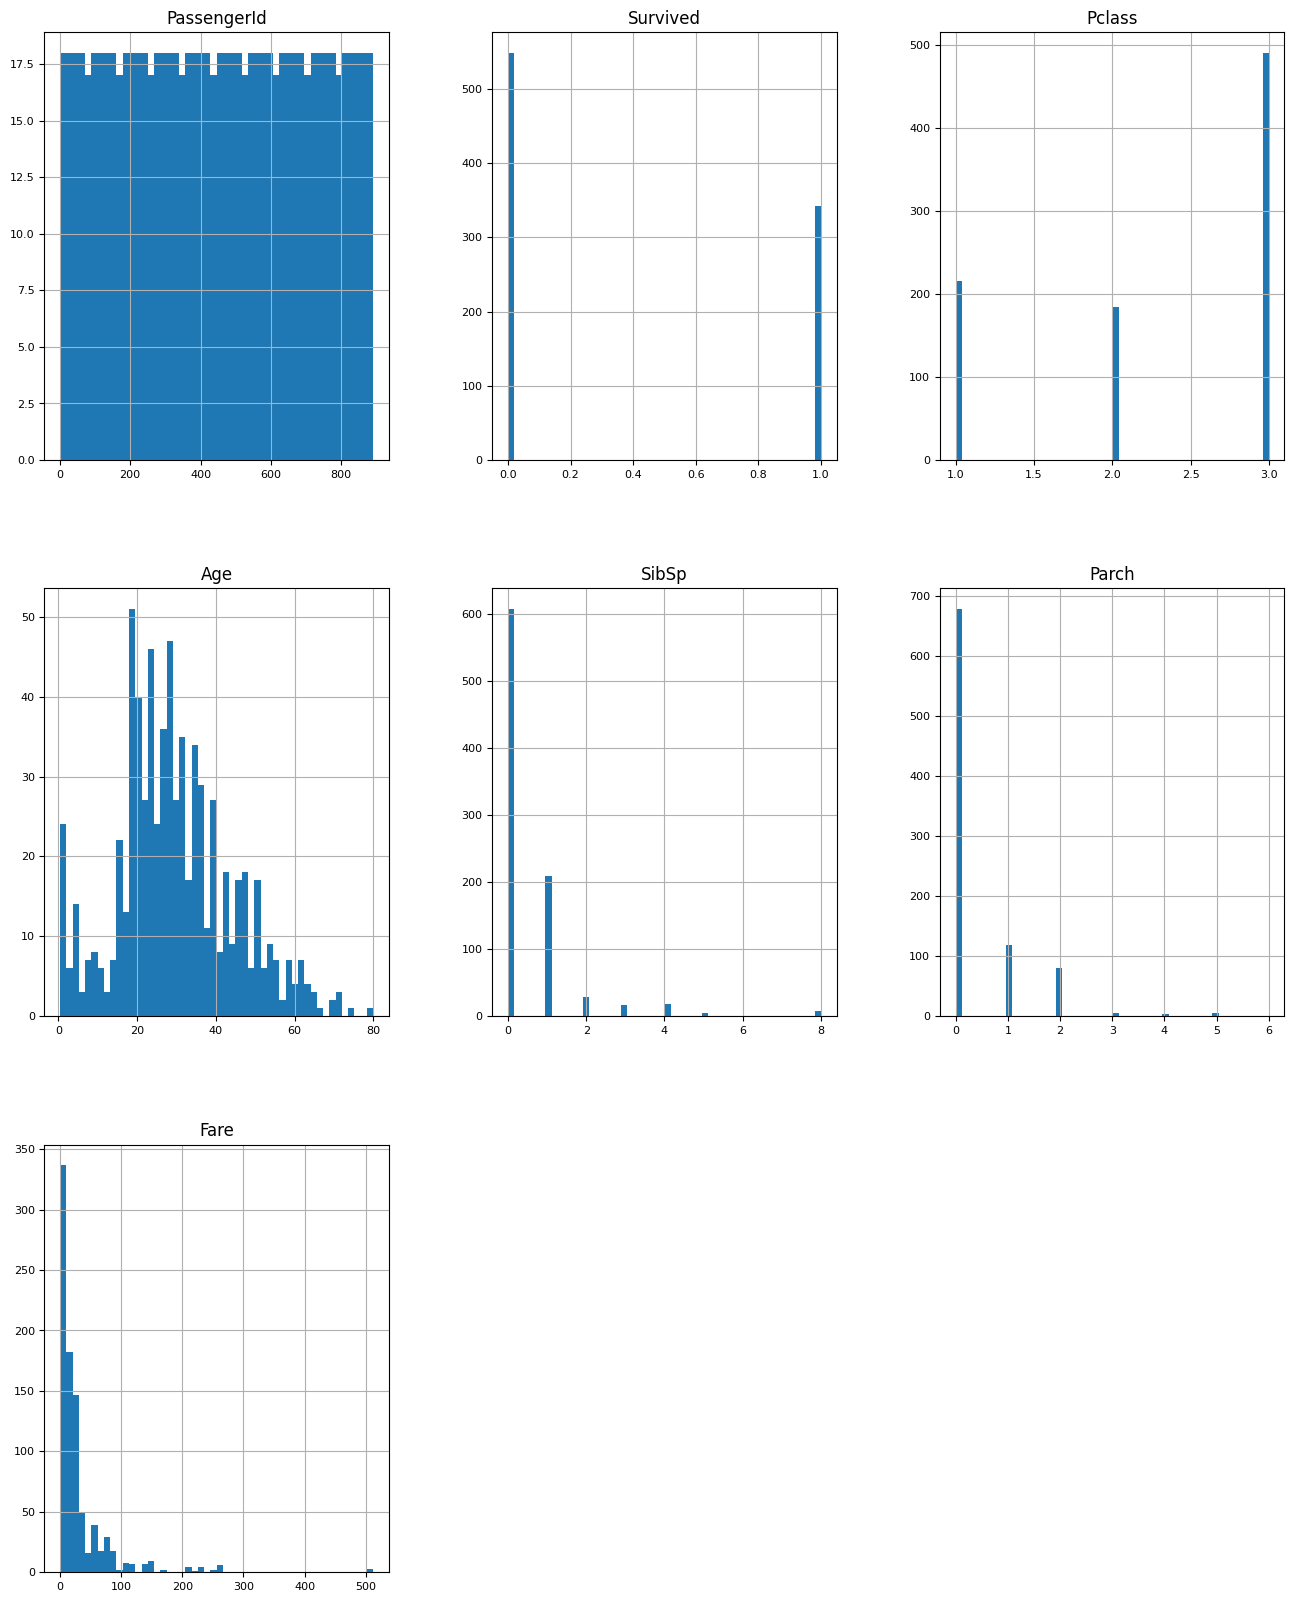

In [30]:
# 1.6 Dibujamos los histogramas de las variables numéricas para conocer su distribución
data.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8);

[Text(0.5, 0, 'PassengerId'),
 Text(1.5, 0, 'Survived'),
 Text(2.5, 0, 'Pclass'),
 Text(3.5, 0, 'Age'),
 Text(4.5, 0, 'SibSp'),
 Text(5.5, 0, 'Parch'),
 Text(6.5, 0, 'Fare')]

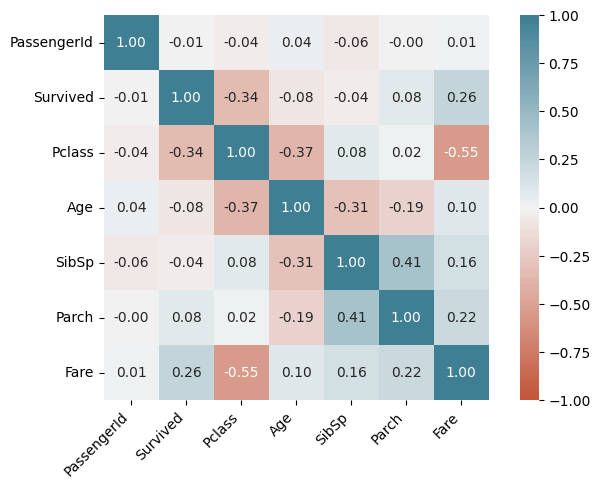

In [31]:
# Calculamos el coeficiente de correlación de Pearson
corr = data.corr(method ='pearson', numeric_only=True)

# Hacemos un headpmap con tamaño ampliado, cuadrado, divergencia con colores y con anotaciones de 2 decimales
plt.figure(figsize=(8,5))
ax = sns.heatmap(
 corr,
 vmin=-1, vmax=1, center=0,
 cmap=sns.diverging_palette(20, 220, n=200),
 square=True, annot=True, fmt=".2f"
)
# Rotamos las etiquetas del eje horizontal
ax.set_xticklabels(
 ax.get_xticklabels(),
 rotation=45,
 horizontalalignment='right'
)

###Paso 3: Realizamos la limpieza de datos: Identificación de valores nulos e imputación de valores faltantes

In [32]:
#Visualizamos de nuevo el total de valores nulos de cada variable del dataset
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [33]:
# Realizamos las transformaciones
data['Age'] = data['Age'].fillna(data['Age'].mean())#Completamos los valores faltantes por la media
data['Cabin'] = data['Cabin'].fillna('Desconocido')#Completamos los valores faltantes  por una nueva categoría "Desconocido"
data['Embarked'] = data['Embarked'].fillna('Desconocido')# Completamos también los valores faltantes por una nueva categoría " Desconocido"

In [34]:
#  Realizamos la selección de variables y eliminamos aquellas que consideramos que no aportan valor al análisis
data = data.drop('Name', axis=1)
data = data.drop('Ticket', axis=1)
data = data.drop('PassengerId', axis=1)
data = data.drop('Fare', axis=1)
data = data.drop('Cabin', axis=1)
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.000000,1,0,S
1,1,1,female,38.000000,1,0,C
2,1,3,female,26.000000,0,0,S
3,1,1,female,35.000000,1,0,S
4,0,3,male,35.000000,0,0,S
5,0,3,male,29.699118,0,0,Q
6,0,1,male,54.000000,0,0,S
7,0,3,male,2.000000,3,1,S
8,1,3,female,27.000000,0,2,S
9,1,2,female,14.000000,1,0,C


In [35]:
#seleccionadas las variables con las que nos quedamos tendremos que ver si hay que hacer alguna transformación como convertir valores string ennuméricos.
#Observamos que las variablse Sex y Embarked son texto.
#Comprobamos los valores que puede adpotar la variable Sex
print('Sex: ',data['Sex'].unique())

Sex:  ['male' 'female']


In [36]:
#Comprobamos los valores que puede adoptar la variable Embarked
print('Embarked: ',data['Embarked'].unique())

Embarked:  ['S' 'C' 'Q' 'Desconocido']


In [37]:
# Sustituimos  las categorías texto por equivalentes numéricos de la variable Sex. En este caso sustituremos los dos tipos de género por los valores 0 y 1:
# Diccionario para mapear valores únicos a números específicos
mapeo_valores = {'male': 0, 'female': 1}  # Puedes ajustar los números según tu preferencia

# Crear una nueva columna numérica utilizando el mapeo
data['Sex'] = data['Sex'].map(mapeo_valores)

data['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

In [38]:
# Sustituimos las categorías de texto por equivalente numéricos de la variable Embarked. En este caso sustituremos las localizaciones de embarque por 0, 1, 2 y 3
# Diccionario para mapear valores únicos a números específicos
mapeo_valores = {'Desconocido': 0, 'S': 1, 'C': 2, 'Q': 3,}  # Puedes ajustar los números según tu preferencia

# Crear una nueva columna numérica utilizando el mapeo
data['Embarked'] = data['Embarked'].map(mapeo_valores)

data['Embarked'].value_counts()

Embarked
1    644
2    168
3     77
0      2
Name: count, dtype: int64

In [39]:
#Vemos que aspecto tiene el dataset ahora
data.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,0,22.000000,1,0,1
1,1,1,1,38.000000,1,0,2
2,1,3,1,26.000000,0,0,1
3,1,1,1,35.000000,1,0,1
4,0,3,0,35.000000,0,0,1
5,0,3,0,29.699118,0,0,3
6,0,1,0,54.000000,0,0,1
7,0,3,0,2.000000,3,1,1
8,1,3,1,27.000000,0,2,1
9,1,2,1,14.000000,1,0,2


### Paso 4: Cargamos librerías y separamos el conjunto de datos para train y test

In [40]:
#Importamos las librerías necesarias para poder aplicar el algoritmo Arboles de decisión y posteriormente evaluarlo

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [41]:
# Separamos los datos en los conjuntos de entrenamiento y test.
from sklearn.model_selection import train_test_split

X, y = data.drop('Survived',axis=1),data['Survived']

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=1)

### Paso 5: Aplicamos el algoritmo de árbol de decisión y evaluamos su rendimiento

In [42]:
#  Construimos el modelo para el clasificador de árbol de decisión. No cambiamos ningún parámetro.
clf = DecisionTreeClassifier()

# Entrenamos el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)

# Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf.predict(X_test)

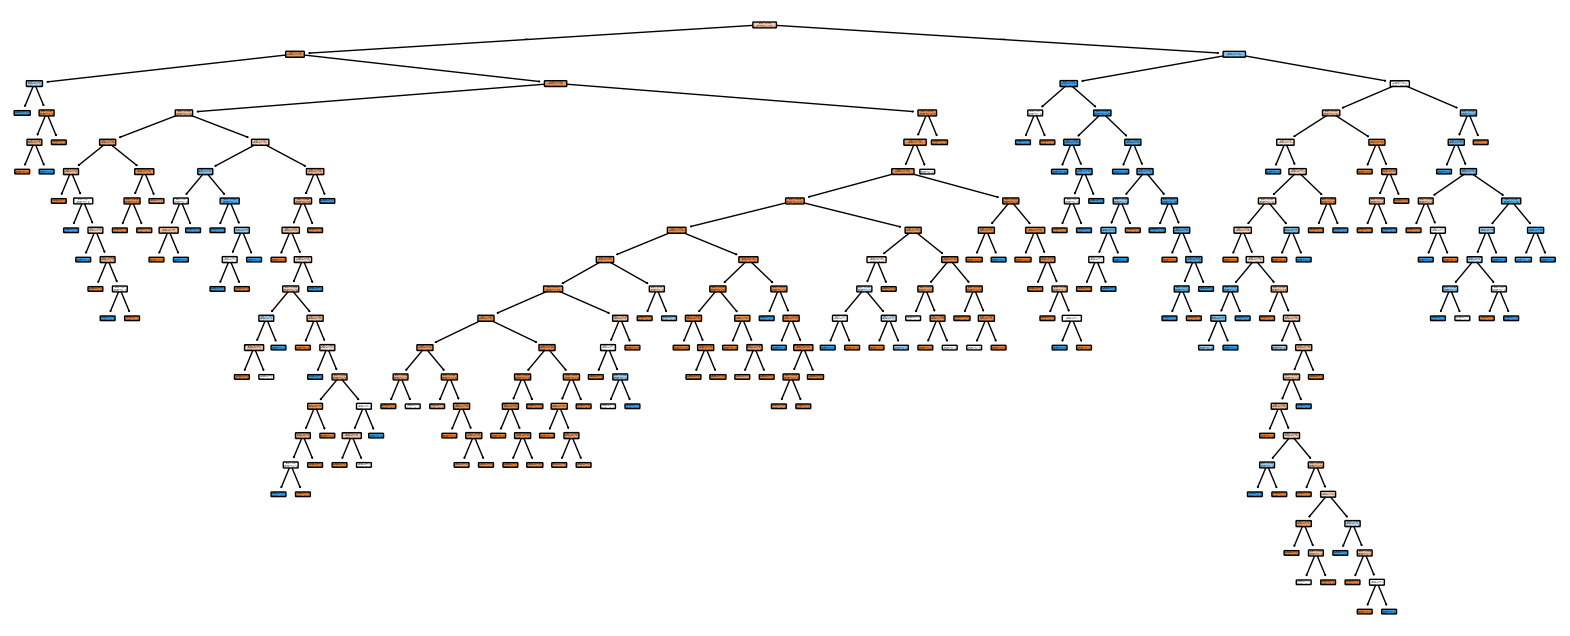

In [43]:
# Visualizamos el resultado del árbol de decisión
plt.figure(figsize=(20, 8))
plot_tree(clf, filled=True, feature_names=X.columns, rounded=True)
plt.show()

In [44]:
#  Construimos el modelo para el clasificador de árbol de decisión modificando el hiperparámetro  max_depth=3
clf = DecisionTreeClassifier(max_depth=3)

# Entrenamos el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)

# Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf.predict(X_test)

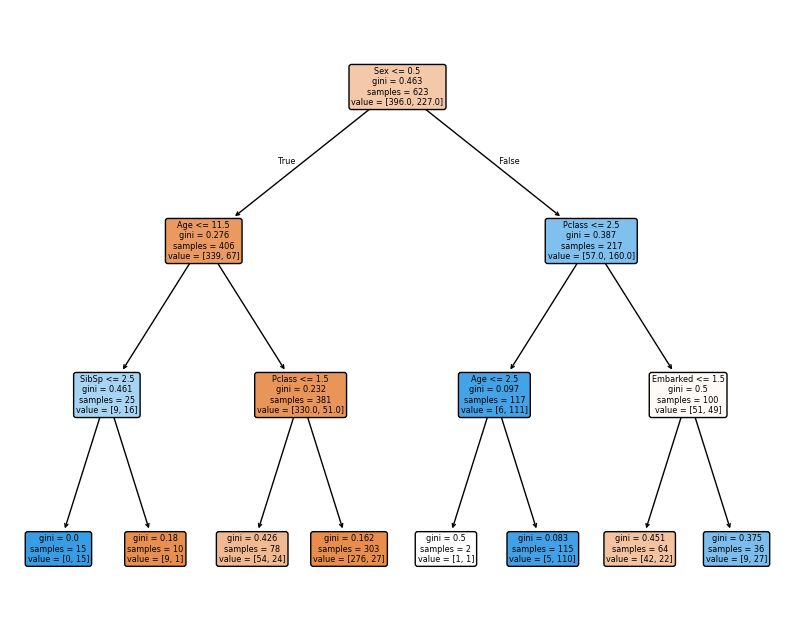

In [45]:
#  Visualizamos el resultado del árbol de decisión
plt.figure(figsize=(10, 8))
plot_tree(clf, filled=True, feature_names=X.columns, rounded=True)
plt.show()

In [46]:
# Obtenemos la matriz de confusión y evaluamos la precisión del modelo
print(f'Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Evaluamos la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')


Matriz de confusión:
[[141  12]
 [ 49  66]]
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       153
           1       0.85      0.57      0.68       115

    accuracy                           0.77       268
   macro avg       0.79      0.75      0.75       268
weighted avg       0.79      0.77      0.76       268

Precisión del modelo: 0.77


### Paso 6: Aplicamos el algoritmo de Random Forest y evaluamos su rendimiento

In [47]:
# Importamos las librerías necesarias para aplicar Random Forest.

from sklearn.ensemble import RandomForestClassifier

In [48]:
# Construimos el modelo para el clasificador de Random Forest con los parámetros establecidos por defecto(en este caso 100)
clf = RandomForestClassifier(random_state=42)

# Entrenamos el modelo a partir de los datos de entrenamiento
clf.fit(X_train, y_train)

#  Probamos ese modelo que hemos entrenado en los datos de test y hacemos la predicción
y_pred = clf.predict(X_test)

In [52]:
#Obtenemos la matriz de confusión
print(f'Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Evaluamos la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')

Matriz de confusión:
[[140  13]
 [ 45  70]]
              precision    recall  f1-score   support

           0       0.76      0.92      0.83       153
           1       0.84      0.61      0.71       115

    accuracy                           0.78       268
   macro avg       0.80      0.76      0.77       268
weighted avg       0.79      0.78      0.78       268

Precisión del modelo: 0.78


In [55]:
# Construimos el modelo para el clasificador de Random Forest modificando el parámetro de número de árboles , n_estimators a 5
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

particion = 'gini'
max_depth = 10
min_samples_split = 10
min_samples_leaf = 2
max_feature = None

rf_classifier = RandomForestClassifier(n_estimators = 5, criterion= particion,
                                       max_depth = max_depth, min_samples_split = min_samples_split,
                                      min_samples_leaf = min_samples_leaf, max_features =None)

# Entrenar el clasificador
rf_classifier.fit(X_train, y_train)

# Realizar predicciones en el conjunto de prueba
y_pred = rf_classifier.predict(X_test)

In [56]:
# Obtenemos la matriz de confusión
print(f'Matriz de confusión:')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Evaluamos la precisión del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Precisión del modelo: {accuracy:.2f}')

Matriz de confusión:
[[136  17]
 [ 41  74]]
              precision    recall  f1-score   support

           0       0.77      0.89      0.82       153
           1       0.81      0.64      0.72       115

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.78      0.78       268

Precisión del modelo: 0.78


###Paso 7: ¿Qué se os ocurre que podemos hacer para obtener un mayor rendimiento del modelo?